# Fast Extragradient Method for Monotone L-Lipschitz Operators

This code outlines the procedure for Lyapunov function discovery for the
Fast Extra Gradient (FEG) method, introduced in "Fast Extra Gradient Methods
for Smooth Structured Nonconvex-Nonconcave Minimax Problems" by Sucheol Lee
and Donghwan Kim (2021). We consider the monotone $L$-Lipschitz operator
setup obtained from their Section 7.1 by taking $\alpha_k=1/L$,
$\beta_k=1/(k+1)$, and $\rho=0$, and recover the residual bound
$\|A(x_N)\|^2 \le 4L^2\|x_0-x_\star\|^2/N^2$.

## Import the required libraries

In [1]:
import pepflow as pf
import pepflow.lyapunov_utils as lu
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display
import IPython.display as ipd

## Define the operator and parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

## Write a function to return the PEPContext for Fast Extragradient

In [3]:
def make_ctx_fast_extragradient(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    A.set_zero_point("x_star")

    for k in range(N):
        if k == 0:
            x.add_tag("x_0.5")
            x = (x - sp.S(1) / L * A(x)).add_tag("x_1")
        else:
            Ax_k = A(x)
            x_half = (
                sp.S(k) / sp.S(k + 1) * x
                + sp.S(1) / sp.S(k + 1) * ctx["x_0"]
                - sp.S(k) / (sp.S(k + 1) * L) * Ax_k
            ).add_tag(f"x_{k}.5")
            x = (
                sp.S(k) / sp.S(k + 1) * x
                + sp.S(1) / sp.S(k + 1) * ctx["x_0"]
                - sp.S(1) / L * A(x_half)
            ).add_tag(f"x_{k + 1}")

    return ctx

## Numerical evidence showing that FEG converges at the rate $\|A(x_N)\|^2 \le \frac{4L^2\|x_0-x_\star\|^2}{N^2}$

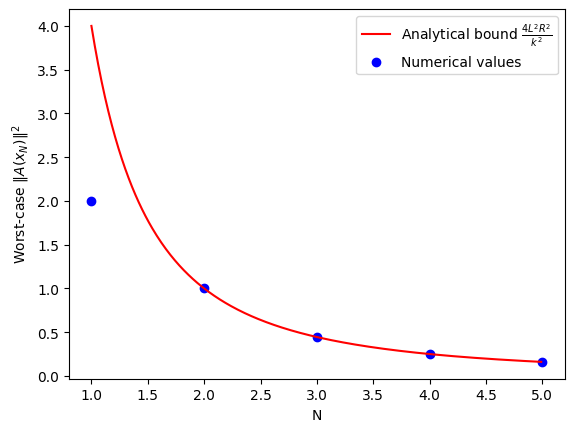

In [4]:
N = 5
L_value = 1
R_value = 1

ctx_plt = make_ctx_fast_extragradient(ctx_name="ctx_plt", N=N)
pb_plt = pf.PEPBuilder(ctx_plt)
pb_plt.add_initial_constraint(
    ((ctx_plt["x_0"] - ctx_plt["x_star"]) ** 2).le(R, name="initial_condition")
)

opt_values = []
for k in range(1, N + 1):
    x_k = ctx_plt[f"x_{k}"]
    pb_plt.set_performance_metric(A(x_k) ** 2)
    result = pb_plt.solve(resolve_parameters={"L": L_value, "R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N + 1)
cont_iters = np.arange(1, N, 0.01)
plt.plot(
    cont_iters,
    4 * L_value**2 * R_value / cont_iters**2,
    "r-",
    label="Analytical bound $\\frac{4L^2R^2}{k^2}$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|A(x_N)\|^2$")
plt.legend()

The bound $4L^2R^2/N^2$ is **tight for $N \geq 2$**.
For $N = 1$ the algorithm reduces to a single gradient step, which achieves $2L^2R^2$ (the formula $4/N^2 = 4$ is a valid but non-tight upper bound there).

## Verification of convergence of FEG

In [5]:
N = sp.S(4)
L_value = sp.S(1)
R_value = sp.S(1)

ctx_prf = make_ctx_fast_extragradient("ctx_prf", N)
x_N_prf = ctx_prf[f"x_{N}"]
_ = A(x_N_prf)

pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R_value, name="initial_condition")
)
pb_prf.set_performance_metric(A(x_N_prf) ** 2)

result = pb_prf.solve(resolve_parameters={"L": L_value, "R": R_value})
print(result.opt_value)

# Dual variables associated with the monotone interpolation conditions of A
lamb_dense = result.get_scalar_constraint_dual_value_in_numpy(A)

0.24999917445620554


### It turns out that no relaxation of dual variables is needed (the solver output is already sparse), so we store the results

In [6]:
# Dual variable associated with the initial condition
tau_sol = result.dual_var_manager.dual_value("initial_condition")

# Dual variables associated with the interpolation conditions of A
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)
lamb_mono_sol = lamb_sol["Monotone Operator Inequality"]
lamb_lip_sol = lamb_sol["Lipschitz Continuous Inequality"]

# Dual variable associated with the Gram matrix G
S_sol = result.get_gram_dual_matrix()

In [7]:
lamb_mono_sol.pprint()
lamb_lip_sol.pprint()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
S_sol.pprint()

<IPython.core.display.Math object>

### The Gram dual matrix $S$ has rank 1

In [9]:
np.linalg.matrix_rank(S_sol.matrix, tol=1e-7)

np.int64(1)

---

## Step 1. Propose a candidate Lyapunov function

### Choose $\mathcal{I}_k$ to contain the Lipschitz inequalities $(x_{j-1/2},x_j)$ for $j=1,\dots,k$ and the monotonicity inequalities $(x_{j-1},x_j)$ for $j=2,\dots,k$.

In [10]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for j in range(1, int(N) + 1):
    partial_sum += lamb_lip_sol(f"x_{j - 1}.5", f"x_{j}") * (
        -A.lipschitz_ineq(f"x_{j - 1}.5", f"x_{j}", ctx_prf)
    )
    if j >= 2:
        partial_sum += lamb_mono_sol(f"x_{j - 1}", f"x_{j}") * (
            -A.monotone_ineq(f"x_{j - 1}", f"x_{j}", ctx_prf)
        )
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate.
### To check rank consistency and conciseness, verify that the ranks of $\mathbf{V}_k$ are constantly 2

In [11]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": L_value})

for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-6)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 2
Rank of lyap[2]: 2
Rank of lyap[3]: 2
Rank of lyap[4]: 2


## Step 3. Build a set of special candidate vectors

In [12]:
lyap_basis_candidate = ctx_prf.basis_vectors()
x = [ctx_prf[f"x_{i}"] for i in range(1, int(N) + 1)]
lyap_basis_candidate += x

for i, j in combinations(range(len(lyap_basis_candidate)), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    diff.add_tag(f"{lyap_basis_candidate[i]}-{lyap_basis_candidate[j]}")
    lyap_basis_candidate.append(diff)

In [13]:
print(lyap_basis_candidate)

[x_0.5, x_star, A(x_0.5), A(x_1), A(x_1.5), A(x_2), A(x_2.5), A(x_3), A(x_3.5), A(x_4), x_1, x_2, x_3, x_4, x_0.5-x_star, x_0.5-A(x_0.5), x_0.5-A(x_1), x_0.5-A(x_1.5), x_0.5-A(x_2), x_0.5-A(x_2.5), x_0.5-A(x_3), x_0.5-A(x_3.5), x_0.5-A(x_4), x_0.5-x_1, x_0.5-x_2, x_0.5-x_3, x_0.5-x_4, x_star-A(x_0.5), x_star-A(x_1), x_star-A(x_1.5), x_star-A(x_2), x_star-A(x_2.5), x_star-A(x_3), x_star-A(x_3.5), x_star-A(x_4), x_star-x_1, x_star-x_2, x_star-x_3, x_star-x_4, A(x_0.5)-A(x_1), A(x_0.5)-A(x_1.5), A(x_0.5)-A(x_2), A(x_0.5)-A(x_2.5), A(x_0.5)-A(x_3), A(x_0.5)-A(x_3.5), A(x_0.5)-A(x_4), A(x_0.5)-x_1, A(x_0.5)-x_2, A(x_0.5)-x_3, A(x_0.5)-x_4, A(x_1)-A(x_1.5), A(x_1)-A(x_2), A(x_1)-A(x_2.5), A(x_1)-A(x_3), A(x_1)-A(x_3.5), A(x_1)-A(x_4), A(x_1)-x_1, A(x_1)-x_2, A(x_1)-x_3, A(x_1)-x_4, A(x_1.5)-A(x_2), A(x_1.5)-A(x_2.5), A(x_1.5)-A(x_3), A(x_1.5)-A(x_3.5), A(x_1.5)-A(x_4), A(x_1.5)-x_1, A(x_1.5)-x_2, A(x_1.5)-x_3, A(x_1.5)-x_4, A(x_2)-A(x_2.5), A(x_2)-A(x_3), A(x_2)-A(x_3.5), A(x_2)-A(x_4), A(x_

## Step 4. Find a basis of $\mathbf{V}_k$ within lyap_basis_candidate

In [14]:
for k in range(len(lyap)):
    print(
        f"V_{k}:",
        lu.vectors_in_column_space(
            lyap[k],
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-6,
            atol=1e-6,
        ),
    )

V_0: []
V_1: [A(x_0.5), A(x_1), x_0.5-x_1, A(x_0.5)-A(x_1)]
V_2: [A(x_2), x_0.5-x_2]
V_3: [A(x_3), x_0.5-x_3]
V_4: [A(x_4), x_0.5-x_4]


### We find that $A(x_k)$ and $x_0-x_k$ are the correct vectors for $V_k$.
### Define $V_k=a_k\|A(x_k)\|^2+b_k\langle A(x_k),x_0-x_k\rangle$.

In [15]:
for k in np.arange(1, len(lyap)):
    aligned_special_vectors_k = [
        A(ctx_prf[f"x_{k}"]),
        ctx_prf["x_0"] - ctx_prf[f"x_{k}"],
    ]
    C_k = lu.find_symmetric_coefficient_matrix(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in aligned_special_vectors_k]
    print(f"V_{k}:")
    pf.pprint_labeled_matrix(C_k, labels_k, labels_k)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


<IPython.core.display.Math object>

V_4:


<IPython.core.display.Math object>

---

## Step 5. Analytic proof

### We first need closed-form expressions of the monotonicity weights, the Lipschitz weights, and $S$.
### This can be checked from the fixed-$N$ certificate and then verified symbolically.

In [16]:
def tag_to_index(tag, N=N):
    idx = tag.split("_", 1)[1]
    if idx == "star":
        return int(N) + 1
    return float(idx)

### Candidate formula for monotonicity weights

In [17]:
def lamb_mono(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    if i == int(i) and j == int(j):
        if 1 <= i < int(N) and j == i + 1:
            return sp.S(4) * int(i) * int(j) / N**2
        if i == int(N) and j == int(N) + 1:
            return sp.S(4) / N
    return 0


lamb_mono_cand = pf.pprint_labeled_matrix(
    lamb_mono,
    lamb_mono_sol.row_names,
    lamb_mono_sol.col_names,
    return_matrix=True,
)

<IPython.core.display.Math object>

### Verify that the proposed formula matches the stored relaxed values

In [18]:
print(
    "Did we guess the right closed form of monotonicity weights?",
    np.allclose(lamb_mono_cand, lamb_mono_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of monotonicity weights? True


### Candidate formula for Lipschitz weights

In [19]:
def lamb_lip(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    if j == int(j) and 1 <= j <= int(N) and i == j - sp.Rational(1, 2):
        return sp.S(2) * int(j) ** 2 / N**2
    return 0


lamb_lip_cand = pf.pprint_labeled_matrix(
    lamb_lip,
    lamb_lip_sol.row_names,
    lamb_lip_sol.col_names,
    return_matrix=True,
)

<IPython.core.display.Math object>

### Verify that the proposed formula matches the stored relaxed values

In [20]:
print(
    "Did we guess the right closed form of Lipschitz weights?",
    np.allclose(lamb_lip_cand, lamb_lip_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of Lipschitz weights? True


### Candidate formula for $S$

In [21]:
x_0 = ctx_prf["x_0"]
x_N = ctx_prf[f"x_{N}"]
x_star = ctx_prf["x_star"]

S_guess = (A(x_N) - sp.S(2) / N * (x_0 - x_star)) ** 2
S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

### Again, verify that the proposed formula matches the solver value

In [22]:
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol.matrix, atol=1e-3),
)

Did we guess the right closed form of S? True


### Finally, we symbolically determine the Lyapunov function coefficients

In [23]:
ctx_fe_lyap = pf.PEPContext("fast_extragradient_lyap_finder").set_as_current()

### Express $V_k-V_{k+1}$ minus the weighted Lipschitz and monotonicity inequalities as a system of equations and solve for $a_k,b_k,a_{k+1},b_{k+1}$.

In [24]:
k = pf.Parameter("k")
N_sym = pf.Parameter("N")
L_sym = sp.S(1)

A_step = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A_step"], L=L_sym)
x_0_sym = pf.Vector(is_basis=True, tags=["x_0"])
x_k = pf.Vector(is_basis=True, tags=["x_k"])

x_half = x_k + 1 / (k + 1) * (x_0_sym - x_k) - k / (k + 1) * A_step(x_k) / L_sym
x_half.add_tag("x_{k+1/2}")
x_k1 = x_k + 1 / (k + 1) * (x_0_sym - x_k) - A_step(x_half) / L_sym
x_k1.add_tag("x_{k+1}")

a_k = pf.Parameter("a_k")
a_k1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_k1 = pf.Parameter("b_{k+1}")

V_k = a_k * A_step(x_k) ** 2 + b_k * A_step(x_k) * (x_0_sym - x_k)
V_k1 = a_k1 * A_step(x_k1) ** 2 + b_k1 * A_step(x_k1) * (x_0_sym - x_k1)

lip_step = -A_step.lipschitz_ineq("x_{k+1/2}", "x_{k+1}", ctx_fe_lyap)
mono_step = -A_step.monotone_ineq("x_k", "x_{k+1}", ctx_fe_lyap)
diff = V_k - V_k1 + 2 * (k + 1) ** 2 / N_sym**2 * lip_step
diff += 4 * k * (k + 1) / N_sym**2 * mono_step

In [25]:
basis = ctx_fe_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

['x_0', 'x_k', 'A_step(x_k)', 'A_step(x_{k+1/2})', 'A_step(x_{k+1})']

In [26]:
pm_lyap = pf.ExpressionManager(
    ctx_fe_lyap,
    resolve_parameters={
        "a_k": sp.Symbol("a_k"),
        "a_{k+1}": sp.Symbol("a_{k+1}"),
        "b_k": sp.Symbol("b_k"),
        "b_{k+1}": sp.Symbol("b_{k+1}"),
        "N": sp.Symbol("N"),
        "k": sp.Symbol("k"),
    },
)

diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, row_index, row_index, precision=None)

<IPython.core.display.Math object>

In [27]:
diff_matrix_sympify = sp.Matrix(diff_matrix)

a_k_sp, a_k1_sp, b_k_sp, b_k1_sp, N_sp, k_sp = sp.symbols("a_k a_{k+1} b_k b_{k+1} N k")
unknowns = (a_k_sp, a_k1_sp, b_k_sp, b_k1_sp)

eqs = list(diff_matrix_sympify)
sol = sp.linsolve(eqs, unknowns)
sol_simplify = sp.factor(sp.nsimplify(sol))

print("Solutions:")
sol_dict = dict(zip(unknowns, next(iter(sol_simplify))))
display(ipd.Math(sp.latex(sol_dict)))

Solutions:


<IPython.core.display.Math object>

### The consistent solution is $a_k=\frac{2k^2}{N^2}$ and $b_k=-\frac{4k}{N^2}$, so
$$
V_k=\frac{2k^2}{N^2}\|A(x_k)\|^2-\frac{4Lk}{N^2}\langle A(x_k),x_0-x_k\rangle.
$$

### Plug these values back into
$$
\begin{aligned}
0
&= V_k - V_{k+1}
+ \frac{2(k+1)^2}{N^2}
\left(
\|A(x_{k+1/2})-A(x_{k+1})\|^2
-\|x_{k+1/2}-x_{k+1}\|^2
\right)\\
&\quad
+ \frac{4k(k+1)}{N^2}
\left(
-\langle A(x_k)-A(x_{k+1}),\,x_k-x_{k+1}\rangle
\right).
\end{aligned}
$$
### This verifies that everything cancels out symbolically.

In [28]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])